In [8]:
import importlib,itertools

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn

import plot_res
importlib.reload( plot_res )
import plot_res as p
from LoadResults import LoadResults


<AxesSubplot:xlabel='Time[s]', ylabel='ReTX'>

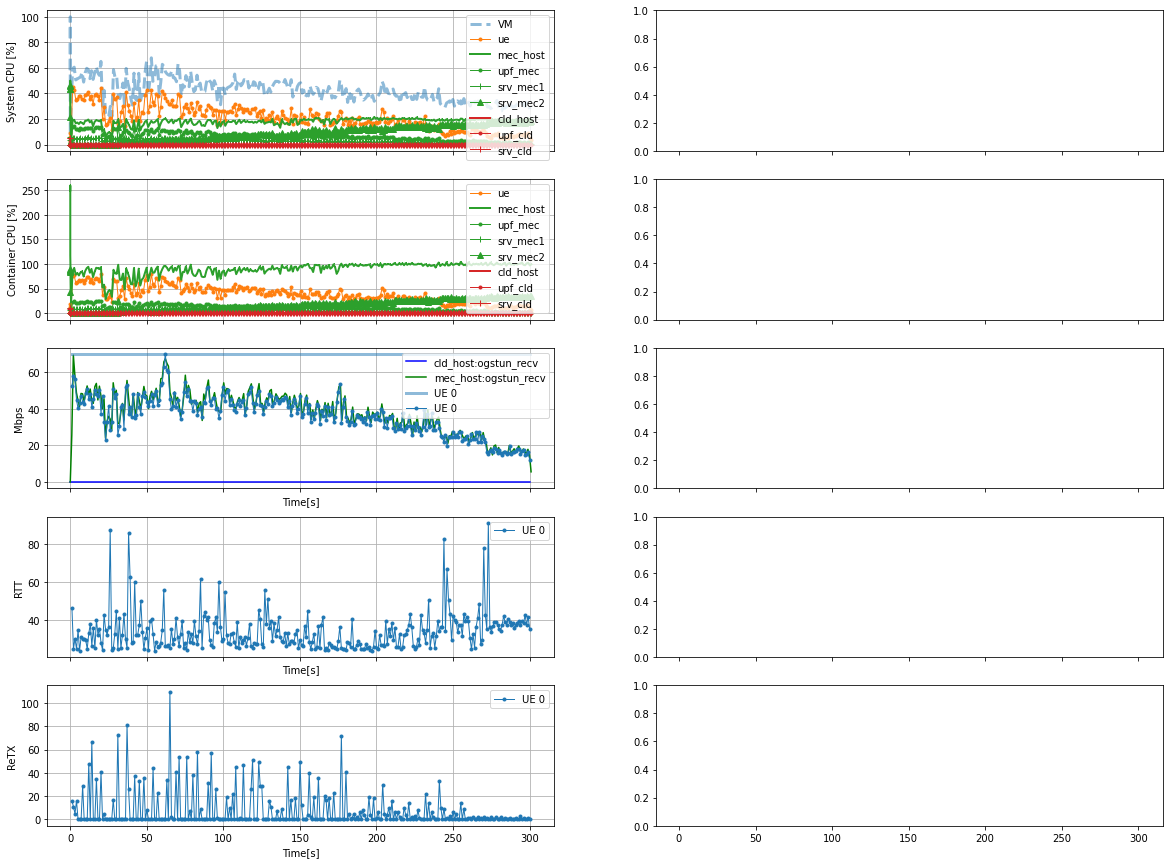

In [18]:
res = p.load_results_json( '../results/Res_scen2b_tcp_cubic_hostcpu0.375.json' )

fig, ax = plt.subplots(nrows=5, ncols=2, sharex=True , figsize=(20,15) )
p.plot_raw_cont_sys_cpu( res, ax[0][0], scen_idx=2)
p.plot_raw_cont_cpu(     res, ax[1][0] , scen_idx=2)
p.plot_raw_upf_thr(         res, ax[2][0] ,  colors=p.get_color_list("base"))
p.plot_raw_iperf_tcp_PerUe( res, ax[2][0] , ue="*", kpi="req",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res, ax[2][0] , ue="*", kpi="bwt",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res, ax[3][0] , ue="*", kpi="rtt",  colors=p.get_color_list() )
p.plot_raw_iperf_tcp_PerUe( res, ax[4][0] , ue="*", kpi="retx",  colors=p.get_color_list() )


In [ ]:
#### pandas interpolation (NOT WORKING)
hcpu = 0.7
res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu}_nue1_sliceFalse.json', load=True )
df_sum, _ = res.df_iperf_bwt()
res.df = res.df.join( df_sum, how="outer" )
df=res.df

dftmp = df['iperf:ue0:bwt:sum'].dropna()
df['iperf:ue0:bwt:sum_intrp'] = dftmp.interpolate( axis=0, method='polynomial', order=2)
display(df)

col = 'iperf:ue0:bwt:sum'
res.df.plot( y=[col,col+'_intrp'])

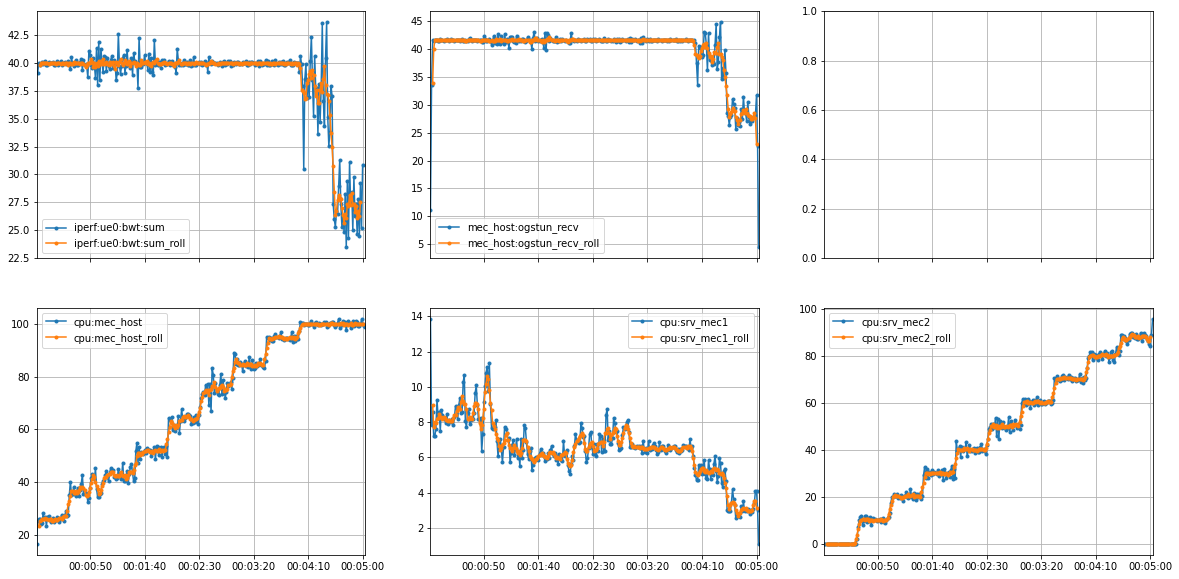

In [9]:
#### Smoothing a time serie with rolling
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu1_nue1_sliceFalse.json', load=True )
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.7_nue1_sliceFalse.json', load=True )
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.375_nue1_sliceFalse.json', load=True )
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.2_nue1_sliceFalse.json', load=True )
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu1_nue1_sliceFalse_1.json', load=True )
res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.7_nue1_sliceFalse_5.json', load=True )
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.375_nue1_sliceFalse_1.json', load=True )
# res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu0.2_nue1_sliceFalse_1.json', load=True )

df_sum, _ = res.df_iperf_bwt()
res.df = res.df.join( df_sum, how="outer" )

fig, axm = plt.subplots(nrows=2, ncols=3, sharex=True , figsize=(20,10) )

ax_it = itertools.cycle( axm.ravel() )

col = 'iperf:ue0:bwt:sum'
roll = res.df[col].rolling( 5 , center=True ).mean()
res.df[col+'_roll'] = roll
res.df.plot( ax=next(ax_it), y=[col,col+'_roll'] , marker='.')

col = 'mec_host:ogstun_recv'
roll = res.df[col].rolling( 5 , center=True ).mean()
res.df[col+'_roll'] = roll
res.df.plot( ax=next(ax_it), y=[col,col+'_roll'] , marker='.')

ax=next(ax_it)

col = 'cpu:mec_host'
roll = res.df[col].rolling( 5 , center=True ).mean()
res.df[col+'_roll'] = roll
res.df.plot( ax=next(ax_it), y=[col,col+'_roll'] , marker='.')

col = 'cpu:srv_mec1'
roll = res.df[col].rolling( 5 , center=True ).mean()
res.df[col+'_roll'] = roll
res.df.plot(ax=next(ax_it), y=[col,col+'_roll'] , marker='.')

col = 'cpu:srv_mec2'
roll = res.df[col].rolling( 5 , center=True ).mean()
res.df[col+'_roll'] = roll
res.df.plot(ax=next(ax_it), y=[col,col+'_roll'] , marker='.')

for ax in axm.ravel():
    ax.grid(visible=True)

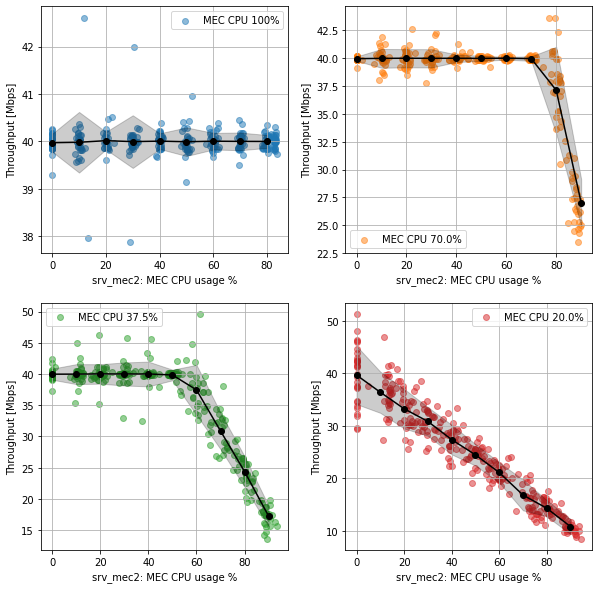

In [29]:
# REGRESSION - SCATTER PLOT - srv_mec2 VS. MEC Throughput
from scipy.interpolate import UnivariateSpline, CubicSpline, InterpolatedUnivariateSpline
from scipy import interpolate

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
fig, ax   = plt.subplots(nrows=2, ncols=2, figsize=(10,10) )
ax_it = itertools.cycle( ax.ravel() )

hcpu = [1, 0.7, 0.375, 0.2]
idx  = [1,   5,     1,   1]
for i in [0,1,2,3]:
    c = next(colors_it)
    ax_t = next(ax_it)

    res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu[i]}_nue1_sliceFalse_{idx[i]}.json', load=True )
    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df

    col = 'iperf:ue0:bwt:sum'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    col = 'mec_host:ogstun_recv'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    col = 'cpu:srv_mec2'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    # thr_col = 'iperf:ue0:bwt:sum_roll'
    thr_col = 'iperf:ue0:bwt:sum'
    # thr_col = 'mec_host:ogstun_recv_roll'
    # thr_col = 'mec_host:ogstun_recv'
    # cpu_col = 'cpu:srv_mec2_roll'
    cpu_col = 'cpu:srv_mec2'


    p.plot_scatter(     df, ax_t, cpu_col, thr_col, "srv_mec2: MEC CPU usage %", "Throughput [Mbps]", label=f"MEC CPU {hcpu[i]*100}%" , color=c)
    # p.plot_scatter_fit( df, ax_t, cpu_col, thr_col,"srv_mec2: MEC CPU usage %", "Throughput [Mbps]",x_lim=[0,100], polyorder=4, label=f"MEC CPU {hcpu*100}%" , color='k', lw=3)
    # display(df)

    #####################################
    # seaborn.regplot( ax=ax_t, x=cpu_col, y=thr_col , data=df, fit_reg=True , order=3, scatter=False, label='order3')
    # seaborn.regplot( ax=ax_t, x=cpu_col, y=thr_col , data=df, fit_reg=True , order=4, scatter=False, label='order4')
    # seaborn.regplot( ax=ax_t, x=cpu_col, y=thr_col , data=df, fit_reg=True , order=5, scatter=False, label='order5')

    #####################################
    # df = df.sort_values(cpu_col) 
    # df = df.dropna()

    # spl = UnivariateSpline(x=df[cpu_col], y=df[thr_col], k=3, s=1000000)
    # # spl = InterpolatedUnivariateSpline(x=df[cpu_col], y=df[thr_col], k=3 )
    # # spl = CubicSpline(x=df[cpu_col], y=df[thr_col] , bc_type='natural')
    # xs = np.linspace(1, 90, 50)
    # ax_t.plot(xs, spl(xs), 'g', lw=3)
    # ax_t.set_ylim(0,50)

    # tck,u = interpolate.splprep([df[cpu_col],df[thr_col]],k=4,s=10000)
    # u=np.linspace(0,1,num=20,endpoint=True)
    # out = interpolate.splev(u,tck)
    # ax_t.plot( out[0], out[1], '.-b' )

    ### ADD average and std by splitting the srv_mec2 in bins
    dftmp = df[[ cpu_col,thr_col ]]
    # bins = pd.cut(df[cpu_col], bins=10) # , labels=("1", "2", "3"))
    # bins_int = [0,10,20,30,40,50,60,70,80,90,100]
    bins_int = [-5,5,15,25,35,45,55,65,75,85,95]
    bins = pd.cut(dftmp[cpu_col], bins_int)
    dftmp = dftmp.groupby(bins).agg(["mean", "std"])
    dftmp["x_val"] = [x+5 for x in bins_int[0 : dftmp.shape[0] ]]

    # display(dftmp)
    dftmp = dftmp.dropna()
    # display(dftmp)
    # display(bins)
    # display(dftmp["cpu:srv_mec2"])
    # display(dftmp["cpu:srv_mec2"]["mean"])
    # x = dftmp[cpu_col]["mean"]
    x = dftmp["x_val"]
    y = dftmp[thr_col]["mean"]
    e = dftmp[thr_col]["std"]
    ax_t.plot( x , y , color='k', marker='o', label=f"MEC CPU {hcpu[i]*100}%")
    ax_t.fill_between(x, y-e, y+e , color='k' , alpha = 0.2)


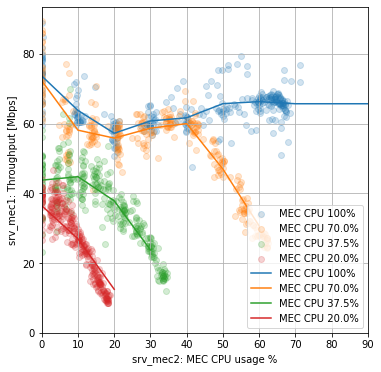

In [6]:
# FINAL FIGURE srv_mec2 VS. MEC Throughput

from scipy.interpolate import UnivariateSpline, CubicSpline, InterpolatedUnivariateSpline
from scipy import interpolate
import copy

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )

fig1, ax1   = plt.subplots( nrows=1, ncols=1, figsize=(6,6) )
final_x = []
final_y = []

hcpu = [1,0.7,0.375,0.2]
res_file = [ "../results/Res_scen2b_tcp_cubic_hostcpu1.json" , 
             "../results/Res_scen2b_tcp_cubic_hostcpu0.7.json" , 
             "../results/Res_scen2b_tcp_cubic_hostcpu0.375.json" , 
             "../results/Res_scen2b_tcp_cubic_hostcpu0.2.json" ]

for i in [0,1,2,3]:
    c = next(colors_it)

    res = LoadResults( res_file[i] , load=True )

    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df

    col = 'iperf:ue0:bwt:sum'
    roll = df[col].rolling( 10 , center=True ).mean()
    df[col+'_roll'] = roll
    col = 'mec_host:ogstun_recv'
    roll = df[col].rolling( 5, center=True ).mean()
    df[col+'_roll'] = roll
    col = 'cpu:srv_mec2'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    p.plot_scatter( df, ax1, 'cpu:srv_mec2', "iperf:ue0:bwt:sum", "srv_mec2: MEC CPU usage %", "Throughput [Mbps]",label=f"MEC CPU {hcpu[i]*100}%", color=c, alpha=0.2)
    # p.plot_scatter( df, ax1, 'cpu:srv_mec2', "iperf:ue0:bwt:sum_roll", "srv_mec2: MEC CPU usage %", "Throughput [Mbps]", color=c, alpha=0.2)
    # p.plot_scatter( df, ax1, 'cpu:srv_mec2', "iperf:ue0:bwt:sum_roll", "srv_mec2: MEC CPU usage %", "Throughput [Mbps]",label=f"MEC CPU {hcpus[i]*100}%",color=c, alpha=0.2)

    ### ADD average and std by splitting the srv_mec2 in bins
    # thr_col = 'iperf:ue0:bwt:sum_roll'
    thr_col = 'iperf:ue0:bwt:sum'
    # thr_col = 'mec_host:ogstun_recv_roll'
    # thr_col = 'mec_host:ogstun_recv'

    # cpu_col = 'cpu:srv_mec2_roll'
    cpu_col = 'cpu:srv_mec2'
    dftmp = df[[ cpu_col,thr_col ]]

    # bins = pd.cut(df[cpu_col], bins=10) # , labels=("1", "2", "3"))
    # bins_int = [0,10,20,30,40,50,60,70,80,90,100]
    bins_int = [-5,5,15,25,35,45,55,65,75,85,95]
    bins = pd.cut(dftmp[cpu_col], bins_int)
    dftmp = dftmp.groupby(bins).agg(["mean", "std"])
    dftmp["x_val"] = [x+5 for x in bins_int[0 : dftmp.shape[0] ]]

    # display(dftmp)
    dftmp = dftmp.dropna()
    x = dftmp["x_val"]
    y = dftmp[thr_col]["mean"]

    final_x.append( list(x) )
    final_y.append( list(y) )

# display(final_x)
# print(final_y)
final_x_c = copy.deepcopy(final_x)
final_y_c = copy.deepcopy(final_y)
final_x_c[0].append(90)
final_y_c[0].append(final_y[0][-1])
final_x_c.append(final_x_c[0])
final_y_c.append([0]*len(final_x_c[0]))
# display(final_x_c)
# print(final_y_c)

for i in [0,1,2,3]:
    ax1.plot( final_x_c[i] , final_y_c[i] , label=f"MEC CPU {hcpu[i]*100}%")
    # ax1.fill_between(final_x_c[i], final_y_c[i], final_y_c[i+1]  , alpha = 0.2)

ax1.legend()
ax1.grid(visible=True)
ax1.set_xlim(0,90)
ax1.set_ylim(bottom=0)
ax1.set_xlabel("srv_mec2: MEC CPU usage %")
ax1.set_ylabel("srv_mec1: Throughput [Mbps]")
ax1.legend()
ax1.set_box_aspect(1)

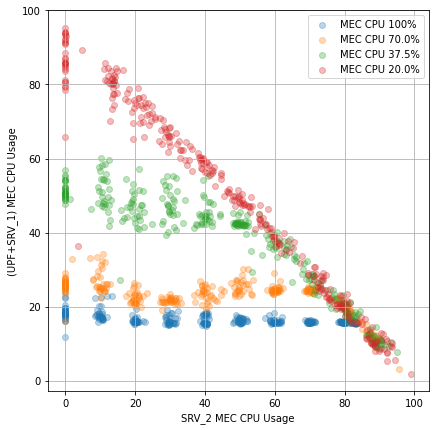

In [4]:
# SCATTER PLOT - SCENARIO 2
colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
fig, ax   = plt.subplots(nrows=1, ncols=1, figsize=(15,7) )

hcpu = [1,0.7,0.375,0.2]
res_file = [ "../results/Res_scen2_tcp_cubic_hostcpu1.json" , 
             "../results/Res_scen2_tcp_cubic_hostcpu0.7.json" , 
             "../results/Res_scen2_tcp_cubic_hostcpu0.375.json" , 
             "../results/Res_scen2_tcp_cubic_hostcpu0.2.json" ]

for i in [0,1,2,3]:
    c = next(colors_it)

    res = LoadResults( res_file[i] , load=True )

    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df

    col = 'cpu:mec_host'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    
    col = 'cpu:srv_mec2'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    
    ax.scatter( df["cpu:srv_mec2"] , df["cpu:srv_mec1"]+df["cpu:upf_mec"] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.3)

ax.set_xlabel( "SRV_2 MEC CPU Usage" )
ax.set_ylabel( "(UPF+SRV_1) MEC CPU Usage" )
ax.grid(visible=True)
ax.legend()
ax.set_box_aspect(1)

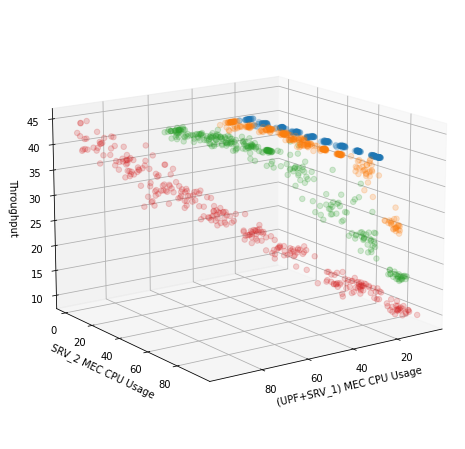

In [4]:
# SCATTER PLOT - SCENARIO 2

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
# fig, ax   = plt.subplots(nrows=1, ncols=2, figsize=(15,7) )

fig1 = plt.figure(figsize=(8,8))
ax1 = fig1.add_subplot(projection='3d')

hcpu = [1, 0.7, 0.375, 0.2]
idx  = [1,   5,     1,   1]
for i in [0,1,2,3]:
    c = next(colors_it)
    res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu[i]}_{idx[i]}.json', load=True )
    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df

    col = 'cpu:mec_host'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    
    col = 'cpu:srv_mec2'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    
    col = 'mec_host:ogstun_recv'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    col = 'iperf:ue0:bwt:sum'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    # ax1.scatter( df['cpu:mec_host'], df['cpu:srv_mec2'], df['iperf:ue0:bwt:sum'] , color=c, alpha=0.2)
    # ax1.set_xlabel("CPU MEC HOST")
    # ax1.set_ylabel("CPU SRV 2")
    # ax1.set_zlabel("Throughput")
    # ax1.view_init(elev=10, azim=60)
    # # ax1.invert_xaxis()

    # ax1.scatter( df['cpu:srv_mec1'], df['cpu:srv_mec2'], df['cpu:upf_mec'] , color=c, alpha=0.2)
    # ax1.set_xlabel("CPU % - SRV 1")
    # ax1.set_ylabel("CPU % - SRV 2")
    # ax1.set_zlabel("CPU % - UPF")
    # # ax1.invert_yaxis() 
    # ax1.view_init(elev=10, azim=20)

    # ax1.scatter( df['cpu:srv_mec1']+df['cpu:upf_mec'], df['cpu:srv_mec2'], df['iperf:ue0:bwt:sum'] , color=c, alpha=0.2)
    ax1.scatter( df['cpu:srv_mec1']+df['cpu:upf_mec'], df['cpu:srv_mec2'], df['iperf:ue0:bwt:sum_roll'] , color=c, alpha=0.2, s=30)
    # ax1.scatter( df['cpu:srv_mec1']+df['cpu:upf_mec'], df['cpu:srv_mec2'], df['mec_host:ogstun_recv'] , color=c, alpha=0.2, marker='s')
    # ax1.scatter( df['cpu:srv_mec1']+df['cpu:upf_mec'], df['cpu:srv_mec2'], df['mec_host:ogstun_recv_roll'] , color=c, alpha=0.2, marker='s')

    ax1.set_xlabel("(UPF+SRV_1) MEC CPU Usage")
    ax1.set_ylabel("SRV_2 MEC CPU Usage")
    ax1.set_zlabel("Throughput")
    ax1.view_init(elev=15, azim=55)
    # ax1.invert_xaxis()



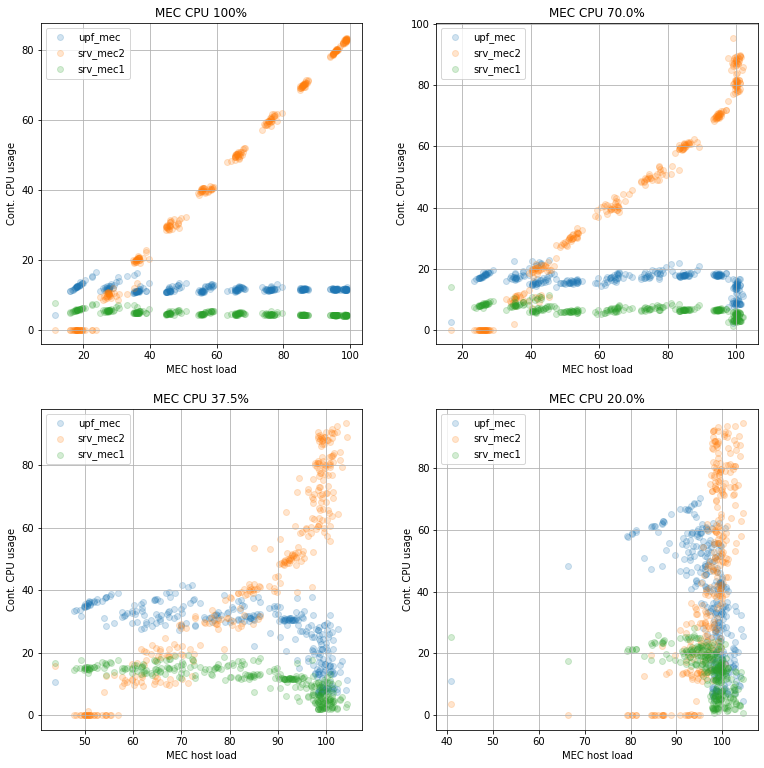

In [5]:
# SCATTER PLOT - Containers CPU Usage
colors_it = itertools.cycle( ["C0","C1","C2","C3"] )

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(13,13) )
ax_it = itertools.cycle( ax.flatten() )


hcpu = [1, 0.7, 0.375, 0.2]
idx  = [1,   5,     1,   1]
for i in [0,1,2,3]:
    res0 = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu[i]}_{idx[i]}.json', load=True )
    df0 = res0.df
    a=next(ax_it)
    p.plot_scatter( df0, a, "cpu:mec_host", "cpu:upf_mec" , "MEC host load","Cont. CPU usage", label="upf_mec" , color="C0", alpha=0.2)
    p.plot_scatter( df0, a, "cpu:mec_host", "cpu:srv_mec2", "MEC host load","Cont. CPU usage", label="srv_mec2", color="C1", alpha=0.2)
    p.plot_scatter( df0, a, "cpu:mec_host", "cpu:srv_mec1", "MEC host load","Cont. CPU usage", label="srv_mec1", color="C2", alpha=0.2)
    a.set_title(f"MEC CPU {hcpu[i]*100}%")



AttributeError: 'AxesSubplot' object has no attribute 'rowNum'

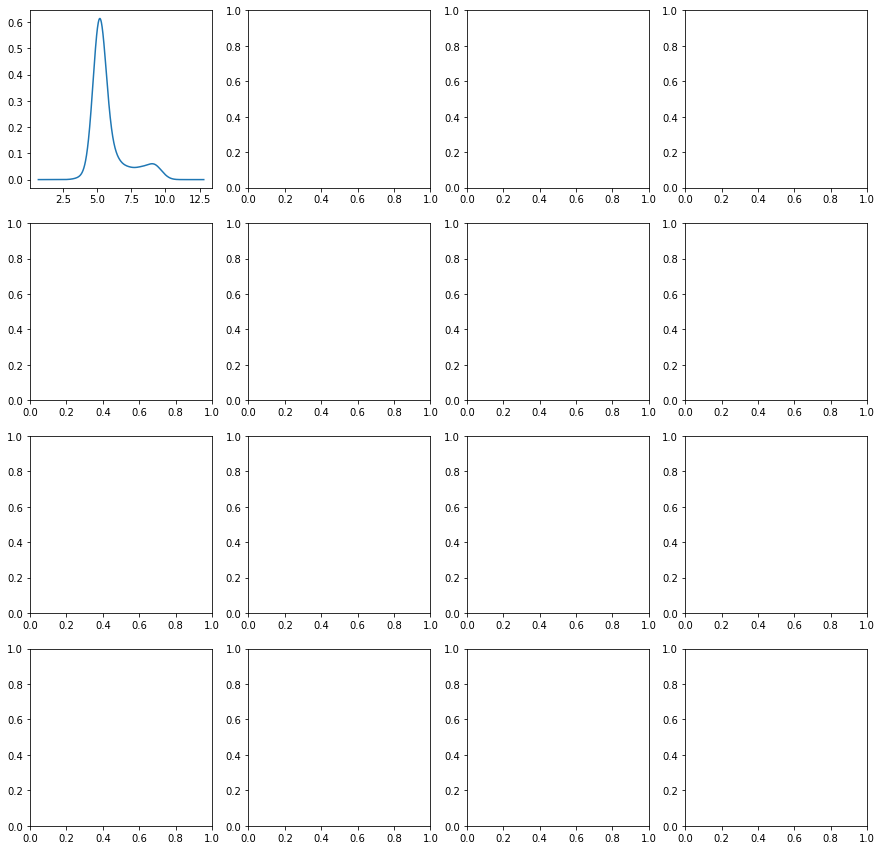

In [20]:
# Variables relation overview - SCENARIO 2

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )

fig1, ax1   = plt.subplots( nrows=4, ncols=4, figsize=(15,15) )#,sharex=True ,sharey=True )

# hcpu = [1, 0.7, 0.375, 0.2]
# idx  = [1,   5,     1,   1]
# hcpu = [0.2, 0.375, 0.7, 1]
# idx  = [1,   1,     5,   1]
hcpu = [1]
# idx  = [1]
# hcpu = [0.7]
# idx  = [5]
# hcpu = [0.375]
# hcpu = [0.2]
# idx  = [1]

cols = [ 'cpu:srv_mec1','cpu:srv_mec2','cpu:upf_mec','iperf:ue0:bwt:sum' ]
# cols = [ 'cpu:srv_mec1','cpu:srv_mec2','cpu:upf_mec','mec_host:ogstun_recv' ]

for i in range(len(hcpu)):
    c = next(colors_it)
    res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu[i]}.json', load=True )
    # res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu[i]}_{idx[i]}.json', load=True )
    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df
    df = df.dropna()
    
    df[cols[0]].plot.density( ax=ax1[0][0], color=c )
    # p.plot_scatter( res.df, ax1[0][0], cols[0],cols[0] , cols[0],cols[0] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.2)

    # for row in range( len(cols) ):
    #     print(row)
    #     minv = min(df[cols[row]].values)-0
    #     maxv = max(df[cols[row]].values)+5
    #     interval = (maxv-minv)/20
    #     df[cols[row]].plot.density( ax=ax1[row,row], color=c, ind=[a for a in np.arange(minv,maxv,interval)])
    #     ax1[row,row].grid(visible=True)

    #     for col in range( len(cols) ):
    #         if col >= row:
    #             continue
    #         p.plot_scatter( res.df, ax1[row][col], cols[col],cols[row] , cols[col],cols[row] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.2)

# for row in range( len(cols) ):
#     ax1[row,row].set_ylim(bottom=0,top=None)

# for row in range( len(cols) ):
#     ax1[row,0].set_xlim(left=0,right=30)
#     ax1[row,1].set_xlim(left=0,right=100)
#     ax1[row,2].set_xlim(left=0,right=80)


AttributeError: 'AxesSubplot' object has no attribute 'rowNum'

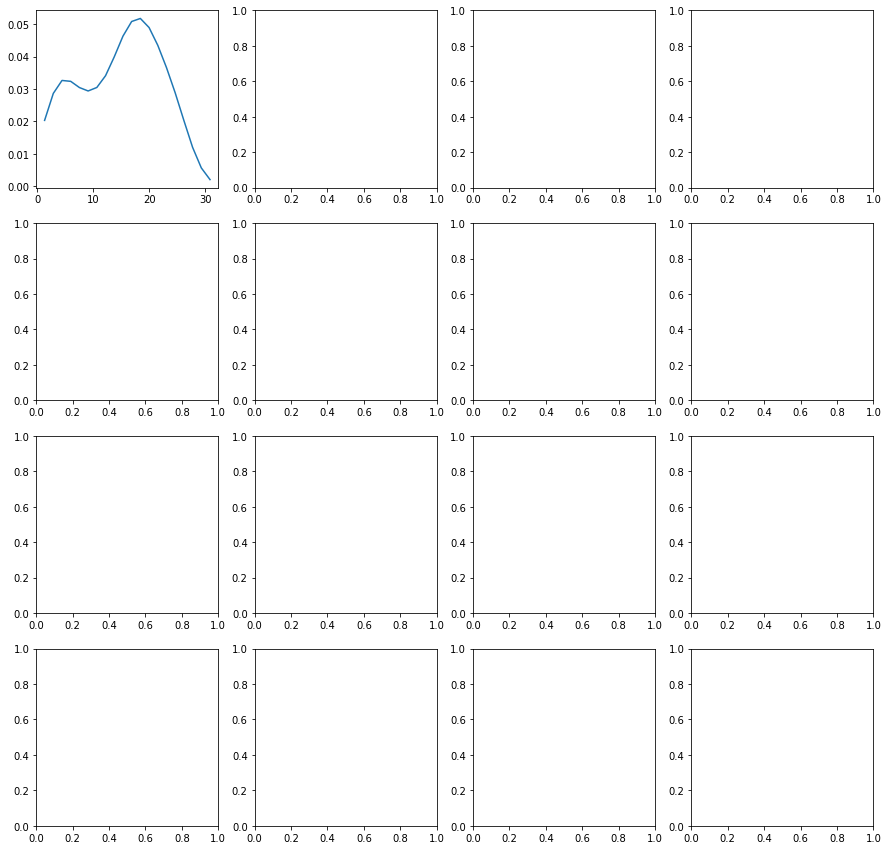

In [7]:
# Variables relation overview - SCENARIO 2

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
# fig, ax   = plt.subplots(nrows=1, ncols=2, figsize=(15,7) )

fig1, ax1   = plt.subplots( nrows=4, ncols=4, figsize=(15,15) )#,sharex=True ,sharey=True )

# hcpu = [1, 0.7, 0.375, 0.2]
# idx  = [1,   5,     1,   1]
hcpu = [0.2, 0.375, 0.7, 1]
idx  = [1,   1,     5,   1]
# hcpu = [1]
# idx  = [1]
# hcpu = [0.7]
# idx  = [5]
# hcpu = [0.375]
# hcpu = [0.2]
# idx  = [1]

cols = [ 'cpu:srv_mec1','cpu:srv_mec2','cpu:upf_mec','iperf:ue0:bwt:sum' ]
# cols = [ 'cpu:srv_mec1','cpu:srv_mec2','cpu:upf_mec','mec_host:ogstun_recv' ]

for i in range(len(hcpu)):
    c = next(colors_it)
    res = Results( f'results/PerfHOST_scen2_tcp_mec_hostcpu{hcpu[i]}.json', load=True )

    df_sum, _ = res.df_iperf_bwt( )
    res.df = res.df.join(df_sum, how="outer")
    df_mean = res.df_iperf_rtt( )
    res.df = res.df.join(df_mean, how="outer")
    df_sum, df_mean = res.df_iperf_retx( )
    res.df = res.df.join(df_mean, how="outer")
    res.df = res.df.join(df_sum, how="outer")

    df = res.df
    df = df.dropna()

    for row in range( len(cols) ):
        minv = min(df[cols[row]].values)-0
        maxv = max(df[cols[row]].values)+5
        interval = (maxv-minv)/20
        df[cols[row]].plot.density( ax=ax1[row,row], color=c, ind=[a for a in np.arange(minv,maxv,interval)])
        ax1[row,row].grid(visible=True)

        for col in range( len(cols) ):
            if col >= row:
                continue
            p.plot_scatter( res.df, ax1[row][col], cols[col],cols[row] , cols[col],cols[row] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.2)

for row in range( len(cols) ):
    ax1[row,row].set_ylim(bottom=0,top=None)

for row in range( len(cols) ):
    ax1[row,0].set_xlim(left=0,right=30)
    ax1[row,1].set_xlim(left=0,right=100)
    ax1[row,2].set_xlim(left=0,right=80)
    
